# Diabetes dataset in sklearn
Number of instances: 442
Number of attributes: 10 (age, sex, bmi, bp, s1, s2, s3, s4, s5, s6)
Target: 病程指數

In [2]:
# Import necessary libraries
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes

In [14]:
# Load and understand data
diabetes = load_diabetes(return_X_y=False)    
# print(diabetes.DESCR)
print("feature names:", diabetes.feature_names)
print("data shape: ", diabetes.data.shape)
print("target shape: ", diabetes.target.shape)

feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
data shape:  (442, 10)
target shape:  (442,)


In [4]:
# 把「給模型當作參考的特徵(feature)」叫做 X， 「要模型去學的答案(label)」叫做 Y
X = diabetes.data
Y = diabetes.target
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 0)
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(353, 10) (353,) (89, 10) (89,)


In [ ]:
# 叫出函數學習機 --> 訓練函數學習機 --> 把函數學習機拿來用
regr = LinearRegression()
regr.fit(x_train, y_train)
y_predict = regr.predict(x_test)
print("預測結果:", y_predict)

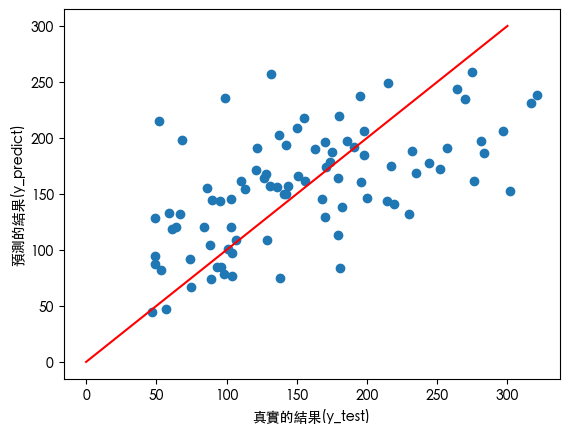

In [7]:
# 真實的結果(y_test)當作 x 座標， 預測的結果(y_predict)當作 y 座標描點在圖上
plt.rcParams['font.sans-serif']=['Heiti TC']
plt.scatter(y_test, y_predict)
plt.plot([0, 300], [0, 300], 'r')
plt.xlabel('真實的結果(y_test)')
plt.ylabel('預測的結果(y_predict)')
plt.show()


In [9]:
# Evaluate model performance using R-squared and Mean Squared Error (MSE)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)
print("Mean Squared Error (MSE):", mse)
print("R-squared (R2 ):", r2)   

Mean Squared Error (MSE): 3424.259334298693
R-squared (R2 ): 0.33223321731061817


- The R2 score varies between 0% and 100%. A high value (close to 100%) indicates that the regression model can explain a large portion of the variance in the target variable.
- In most cases, a low value shows a low level of correlation, meaning a regression model that is not valid.
- 看起來效果不是很好，理由可能是:
  - 給的特徵不足以預測糖尿病
  - 模型的參數沒有調整好
  - 不適合使用線性迴歸建模